# 03 - Visualizações: Acesso à Energia Elétrica Adequada no Amazonas
**Público-alvo:** ANEEL / Governo do Amazonas  
**Dados:** saídas do notebook 01


In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

mun       = gpd.read_file('municipios-am.geojson')
rural_urb = pd.read_csv('energia-am-rural-urbano.csv')

print("Dados carregados. Gerando visualizações...")


Dados carregados. Gerando visualizações...


---
## Visualização 1: Mapa coroplético - % sem acesso adequado à energia por município

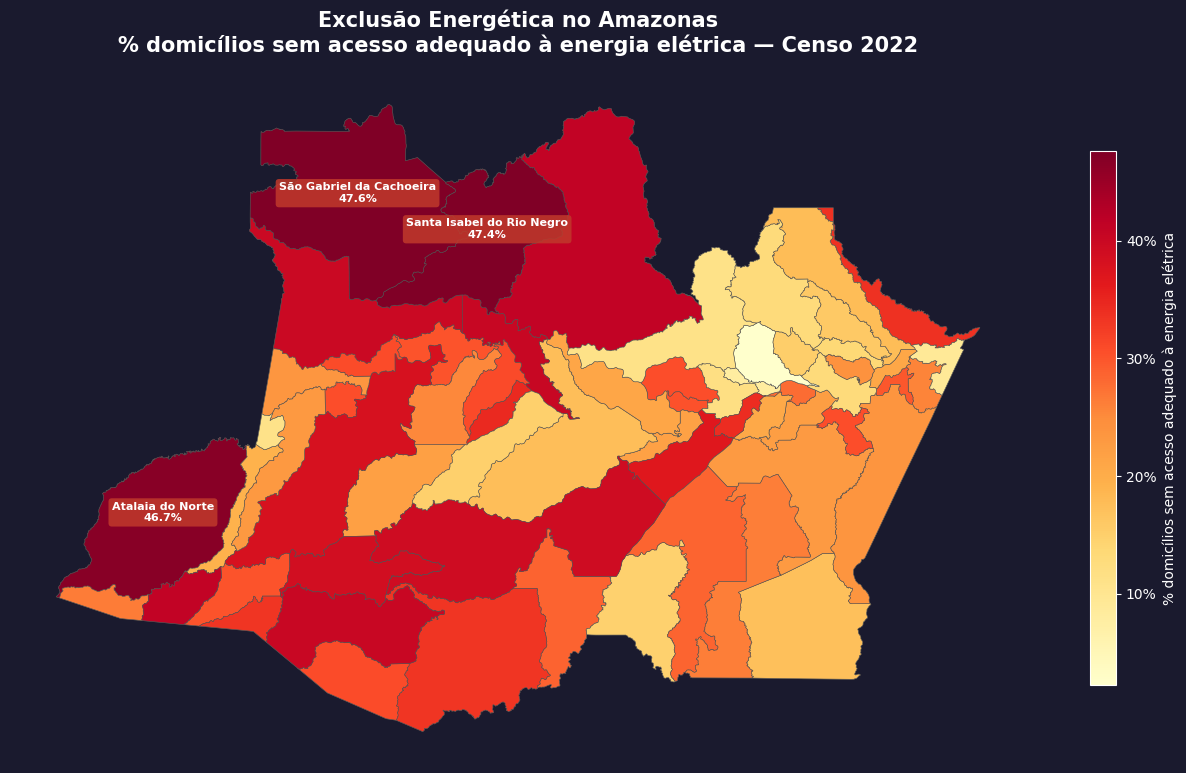

Visualização 1 salva!


In [2]:
fig, ax = plt.subplots(figsize=(13, 10))

# fundo
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

# mapa base
mun.plot(
    ax=ax,
    color='#2a2a4a',
    edgecolor='#444',
    linewidth=0.4
)

# mapa coroplético
mun_sem = mun.dropna(subset=['pct_sem_energia'])

mun_sem.plot(
    column='pct_sem_energia',
    ax=ax,
    cmap='YlOrRd',
    legend=True,
    legend_kwds={
        'label': '% domicílios sem acesso adequado à energia elétrica',
        'orientation': 'vertical',
        'shrink': 0.55,
        'format': '%.0f%%'
    },
    edgecolor='#555',
    linewidth=0.4
)

# pega a colorbar (legenda)
cbar = fig.axes[-1]

# deixa textos da legenda brancos
cbar.yaxis.label.set_color('white')
cbar.tick_params(colors='white')

# opcional: borda da legenda mais clara
for spine in cbar.spines.values():
    spine.set_edgecolor('white')

# título
ax.set_title(
    'Exclusão Energética no Amazonas\n'
    '% domicílios sem acesso adequado à energia elétrica — Censo 2022',
    fontsize=15,
    fontweight='bold',
    color='white',
    pad=15
)

ax.axis('off')

# top 3 municípios
top3 = mun_sem.nlargest(3, 'pct_sem_energia')

for _, row in top3.iterrows():
    cx = row.geometry.centroid.x
    cy = row.geometry.centroid.y

    ax.annotate(
        f"{row['NM_MUN']}\n{row['pct_sem_energia']:.1f}%",
        xy=(cx, cy),
        fontsize=8,
        ha='center',
        color='white',
        fontweight='bold',
        bbox=dict(
            boxstyle='round,pad=0.3',
            fc='#c0392b',
            alpha=0.85,
            ec='none'
        )
    )

plt.tight_layout()

plt.savefig(
    'viz1_mapa_coropletico.png',
    dpi=150,
    bbox_inches='tight',
    facecolor=fig.get_facecolor()
)

plt.show()

print("Visualização 1 salva!")

---
## Visualização 2: Top 15 municípios com maior exclusão energética

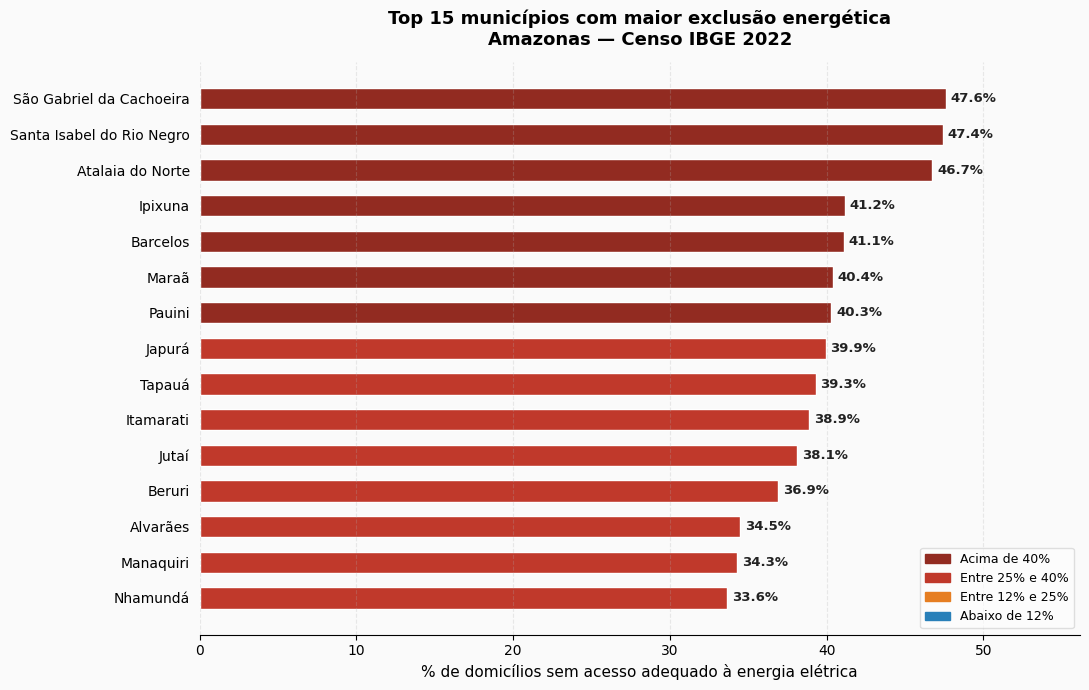

Visualização 2 salva!


In [3]:
top15 = mun.dropna(subset=['pct_sem_energia']).nlargest(15, 'pct_sem_energia').sort_values('pct_sem_energia')

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#fafafa')
ax.set_facecolor('#fafafa')

def cor_barra(p):
    if p >= 40: return '#922b21'
    elif p >= 25: return '#c0392b'
    elif p >= 12: return '#e67e22'
    else:         return '#2980b9'

cores  = [cor_barra(p) for p in top15['pct_sem_energia']]
barras = ax.barh(top15['NM_MUN'], top15['pct_sem_energia'],
                 color=cores, edgecolor='white', height=0.6)

for barra, val in zip(barras, top15['pct_sem_energia']):
    ax.text(val + 0.3, barra.get_y() + barra.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9.5, color='#222', fontweight='bold')

ax.set_xlabel('% de domicílios sem acesso adequado à energia elétrica', fontsize=11)
ax.set_title('Top 15 municípios com maior exclusão energética\nAmazonas — Censo IBGE 2022',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(0, top15['pct_sem_energia'].max() * 1.18)
ax.grid(axis='x', alpha=0.25, linestyle='--')
ax.spines[['top','right','left']].set_visible(False)
ax.tick_params(left=False)

patches = [
    mpatches.Patch(color='#922b21', label='Acima de 40%'),
    mpatches.Patch(color='#c0392b', label='Entre 25% e 40%'),
    mpatches.Patch(color='#e67e22', label='Entre 12% e 25%'),
    mpatches.Patch(color='#2980b9', label='Abaixo de 12%'),
]
ax.legend(handles=patches, loc='lower right', fontsize=9, framealpha=0.6)

plt.tight_layout()
plt.savefig('viz2_top15_barras.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualização 2 salva!")


---
## Visualização 3: Scatter - distância a Manaus × % sem energia

Este gráfico mostra se municípios mais distantes da capital tendem a ter maior exclusão energética.
O tamanho de cada ponto representa o número de domicílios do município.


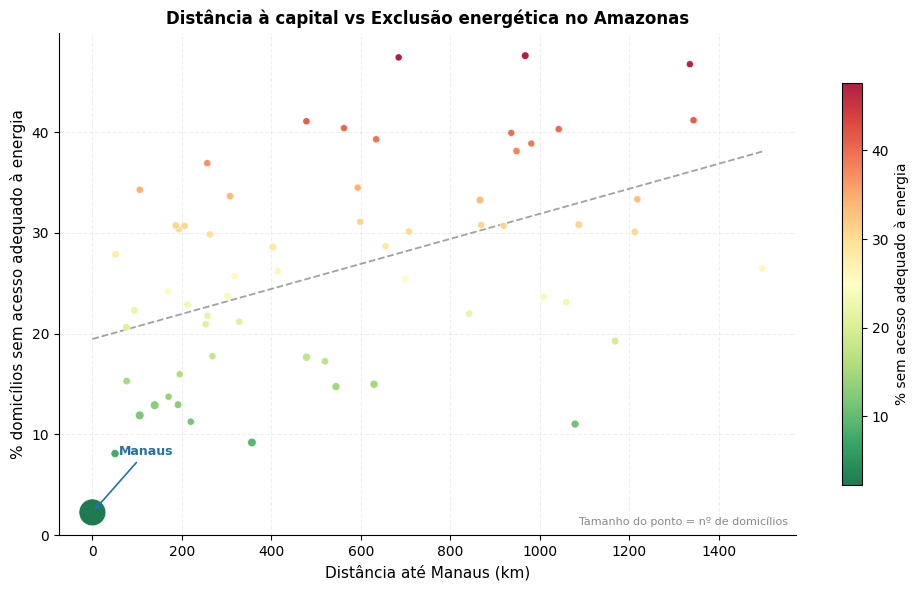

Visualização 3 salva!


In [4]:
df_sc    = mun[['NM_MUN','pct_sem_energia','dist_manaus_km','total_dom']].dropna()
r_v, p_v = stats.pearsonr(df_sc['dist_manaus_km'], df_sc['pct_sem_energia'])

fig, ax = plt.subplots(figsize=(10, 6))

tamanho = (df_sc['total_dom'] / df_sc['total_dom'].max()) * 350 + 25

scatter = ax.scatter(
    df_sc['dist_manaus_km'], df_sc['pct_sem_energia'],
    s=tamanho,
    c=df_sc['pct_sem_energia'],
    cmap='RdYlGn_r',
    edgecolors='white', linewidths=0.5,
    alpha=0.88, zorder=3
)

m, b = np.polyfit(df_sc['dist_manaus_km'], df_sc['pct_sem_energia'], 1)
x_l  = np.linspace(df_sc['dist_manaus_km'].min(), df_sc['dist_manaus_km'].max(), 200)
ax.plot(x_l, m*x_l + b, '--', color='#444', lw=1.3, alpha=0.5, label='Tendência')

row_m = df_sc[df_sc['NM_MUN'] == 'Manaus']
if not row_m.empty:
    ax.annotate('Manaus',
        xy=(row_m['dist_manaus_km'].values[0], row_m['pct_sem_energia'].values[0]),
        xytext=(60, 8), fontsize=9, color='#2471a3', fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='#2471a3', lw=1.2))

plt.colorbar(scatter, ax=ax, label='% sem acesso adequado à energia', shrink=0.8)
ax.set_xlabel('Distância até Manaus (km)', fontsize=11)
ax.set_ylabel('% domicílios sem acesso adequado à energia', fontsize=11)
ax.set_title('Distância à capital vs Exclusão energética no Amazonas', fontsize=12, fontweight='bold')
ax.grid(alpha=0.2, linestyle='--')
ax.spines[['top','right']].set_visible(False)
ax.text(0.99, 0.02, 'Tamanho do ponto = nº de domicílios',
        transform=ax.transAxes, ha='right', fontsize=8, color='#888')

plt.tight_layout()
plt.savefig('viz3_scatter_distancia.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualização 3 salva!")


---
## Visualização 4: Mapa de bolhas - porte do município × exclusão

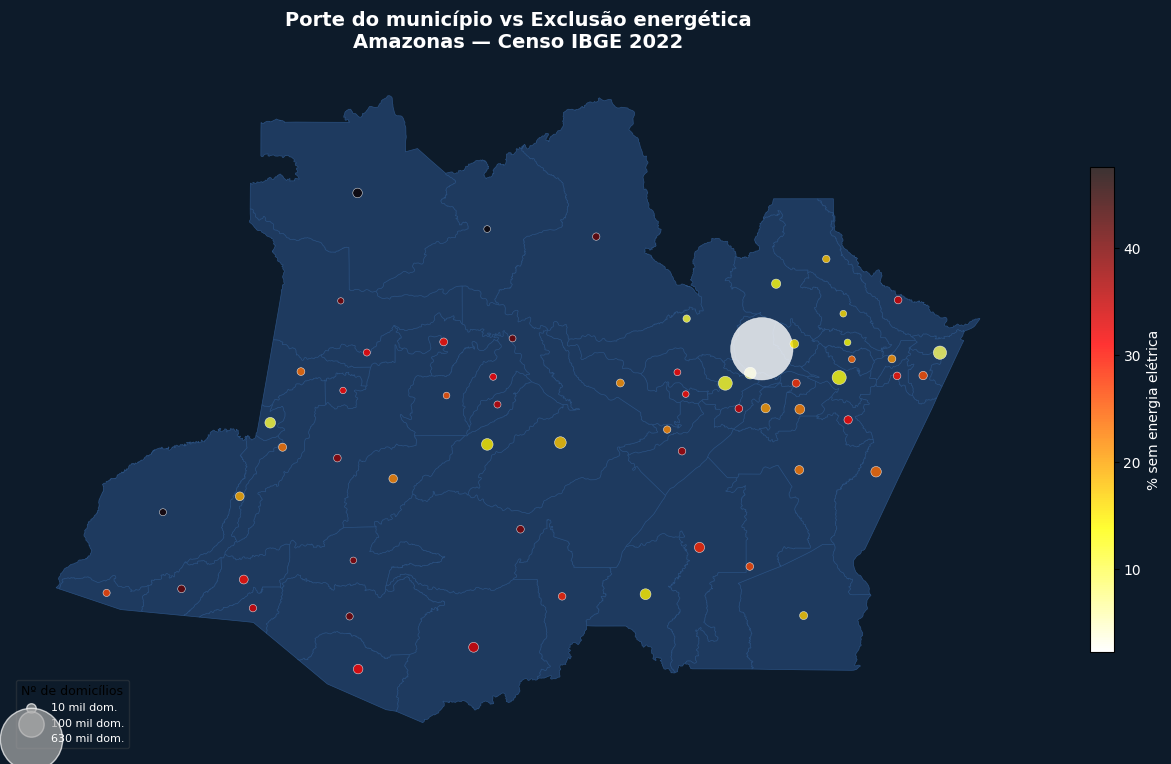

Visualização 4 salva!


In [5]:
fig, ax = plt.subplots(figsize=(13, 10))
fig.patch.set_facecolor('#0d1b2a')
ax.set_facecolor('#0d1b2a')

mun.plot(ax=ax, color='#1e3a5f', edgecolor='#2a5080', linewidth=0.5)

df_bub = mun.dropna(subset=['pct_sem_energia','total_dom'])
cent   = df_bub.geometry.centroid
norm   = mcolors.Normalize(vmin=df_bub['pct_sem_energia'].min(),
                            vmax=df_bub['pct_sem_energia'].max())
tamanho = (df_bub['total_dom'] / df_bub['total_dom'].max()) * 2000 + 15

sc = ax.scatter(cent.x, cent.y, s=tamanho,
                c=df_bub['pct_sem_energia'], cmap='hot_r', norm=norm,
                alpha=0.8, edgecolors='white', linewidths=0.4, zorder=4)
cb = plt.colorbar(sc, ax=ax, shrink=0.5)
cb.set_label('% sem energia elétrica', color='white')
plt.setp(cb.ax.yaxis.get_ticklabels(), color='white')

ax.set_title('Porte do município vs Exclusão energética\nAmazonas — Censo IBGE 2022',
             fontsize=14, fontweight='bold', color='white', pad=12)
ax.axis('off')

for qtd, label in [(10000,'10 mil dom.'),(100000,'100 mil dom.'),(630000,'630 mil dom.')]:
    s = (qtd / df_bub['total_dom'].max()) * 2000 + 15
    ax.scatter([], [], s=s, c='#aaa', alpha=0.7, edgecolors='white', label=label)
ax.legend(title='Nº de domicílios', title_fontsize=9, loc='lower left',
          fontsize=8, framealpha=0.3, labelcolor='white',
          facecolor='#0d1b2a', edgecolor='#555')

plt.tight_layout()
plt.savefig('viz4_mapa_bolhas.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Visualização 4 salva!")


---
## Visualização 5: Comparativo rural × urbano por mesorregião

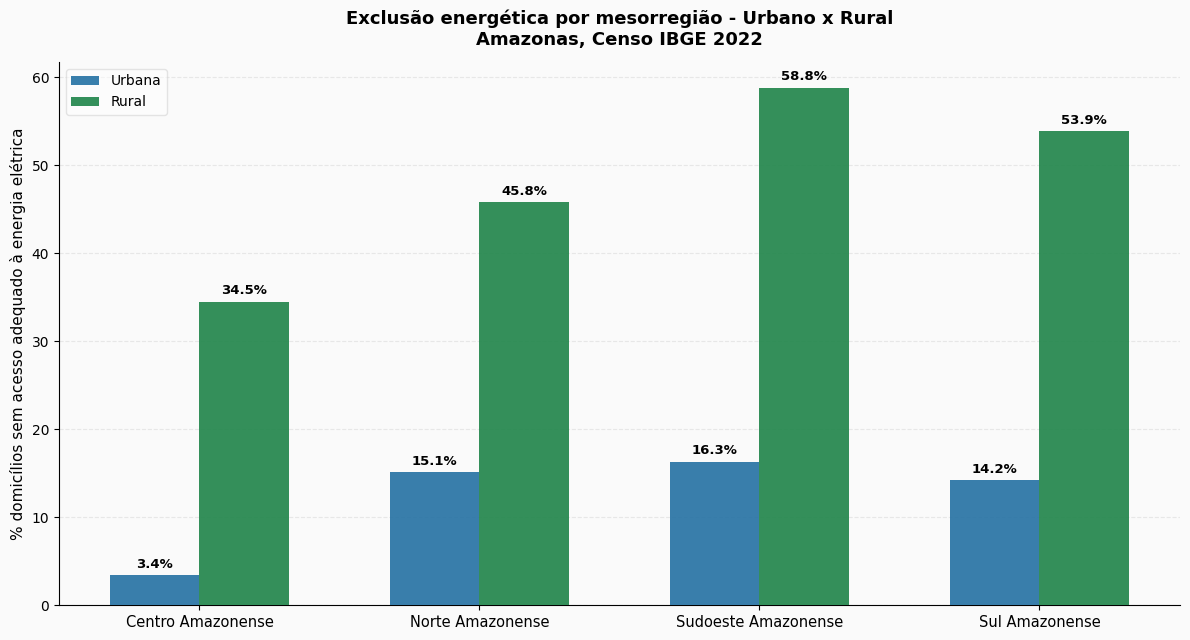

Visualização 5 salva!

=== Todas as 5 visualizações geradas! ===


In [6]:
mesorregioes = {
    'Norte Amazonense':    ['Barcelos','Santa Isabel do Rio Negro','São Gabriel da Cachoeira',
                             'Presidente Figueiredo','Rio Preto da Eva','Santa Cruz do Rio Preto da Eva',
                             'Novo Airão'],
    'Sudoeste Amazonense': ['Eirunepé','Envira','Itamarati','Ipixuna','Atalaia do Norte',
                             'Benjamin Constant','Tabatinga','São Paulo de Olivença',
                             'Amaturá','Tonantins','Santo Antônio do Içá','Jutaí','Juruá'],
    'Centro Amazonense':   ['Manaus','Iranduba','Manacapuru','Careiro','Careiro da Várzea',
                             'Autazes','Borba','Manicoré','Humaitá','Apuí','Novo Aripuanã',
                             'Aripuanã','Itacoatiara','Silves','Urucurituba','Maués',
                             'Barreirinha','Parintins','Nhamundá'],
    'Sul Amazonense':      ['Coari','Tefé','Alvarães','Uarini','Maraã','Fonte Boa',
                             'Japurá','Codajás','Anori','Anamã','Caapiranga','Tapauá',
                             'Pauini','Lábrea','Boca do Acre','Beruri']
}

def get_meso(nome):
    for meso, cidades in mesorregioes.items():
        if nome in cidades:
            return meso
    return 'Centro Amazonense'

rural_urb['mesorregiao'] = rural_urb['NM_MUN'].apply(get_meso)

por_meso = rural_urb.groupby(['mesorregiao','SITUACAO']).agg(
    total_dom   = ('total_dom',   'sum'),
    sem_energia = ('sem_energia', 'sum')
).reset_index()
por_meso['pct_sem'] = (por_meso['sem_energia'] / por_meso['total_dom'] * 100).round(1)

pivot = por_meso.pivot(index='mesorregiao', columns='SITUACAO', values='pct_sem').fillna(0)

fig, ax = plt.subplots(figsize=(12, 6.5))
fig.patch.set_facecolor('#fafafa')
ax.set_facecolor('#fafafa')

x    = np.arange(len(pivot))
larg = 0.32

b_urb = ax.bar(x - larg/2, pivot.get('Urbana', 0), larg,
               label='Urbana', color='#2471a3', alpha=0.9, zorder=3)
b_rur = ax.bar(x + larg/2, pivot.get('Rural',  0), larg,
               label='Rural',  color='#1e8449', alpha=0.9, zorder=3)

for b in list(b_urb) + list(b_rur):
    h = b.get_height()
    if h > 0.5:
        ax.text(b.get_x() + b.get_width()/2, h + 0.5,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=9.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(pivot.index, fontsize=10.5)
ax.set_ylabel('% domicílios sem acesso adequado à energia elétrica', fontsize=11)
ax.set_title('Exclusão energética por mesorregião - Urbano x Rural\nAmazonas, Censo IBGE 2022',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10, framealpha=0.5)
ax.grid(axis='y', alpha=0.25, linestyle='--')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('viz5_meso_rural_urbano.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualização 5 salva!")
print()
print("=== Todas as 5 visualizações geradas! ===")
